# Computing P-values and Confidence Intervals

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute p-values for hypothesis tests
- Calculate confidence intervals for population parameters
- Interpret p-values and confidence intervals
- Understand the relationship between p-values and confidence intervals

## 🔗 Prerequisites

- ✅ Understanding of hypothesis testing
- ✅ Understanding of sampling and estimation
- ✅ Python, NumPy, SciPy knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 03, Unit 5**:
- Computing p-values and confidence intervals
- **Source:** `DETAILED_UNIT_DESCRIPTIONS.md` - Unit 5 Practical Content

---

## Introduction

**P-values** measure evidence against the null hypothesis, and **confidence intervals** provide a range of plausible values for population parameters.

## 📥 Inputs & 📤 Outputs | المدخلات والمخرجات

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("✅ Libraries imported!")
print("\nComputing P-values and Confidence Intervals")
print("=" * 60)

✅ Libraries imported!

Computing P-values and Confidence Intervals


## Part 1: Computing P-values


In [2]:
import pandas as pd
print("=" * 60)
print("Part 1: Computing P-values")
print("=" * 60)

# Generate sample data: measurements with true mean 50
np.random.seed(42)
true_mean = 50
sample = np.random.normal(true_mean, 10, 100)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)

print(f"\nSample: n = {len(sample)}")
print(f"Sample mean: {sample_mean:.4f}")
print(f"Sample std:  {sample_std:.4f}")

# P-value: probability of observing data this extreme IF H0 is true
# One-sample t-test: H0: mu = hypothesized value
for h0 in [50, 52, 55]:
    t_stat, p_value = stats.ttest_1samp(sample, h0)
    decision = "Reject H0 (p < 0.05)" if p_value < 0.05 else "Fail to reject H0 (p >= 0.05)"
    print(f"\nTest - H0: mu = {h0}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value:     {p_value:.4f}")
    print(f"  Decision:    {decision}")

print("\nInterpretation: A small p-value means the observed sample would be")
print("very unlikely if H0 were true - evidence AGAINST H0.")

print("\n\u2705 P-values computed!")


Part 1: Computing P-values

Sample: n = 100
Sample mean: 48.9615
Sample std:  9.0817

Test - H0: mu = 50
  t-statistic: -1.1435
  p-value:     0.2556
  Decision:    Fail to reject H0 (p >= 0.05)

Test - H0: mu = 52
  t-statistic: -3.3457
  p-value:     0.0012
  Decision:    Reject H0 (p < 0.05)

Test - H0: mu = 55
  t-statistic: -6.6491
  p-value:     0.0000
  Decision:    Reject H0 (p < 0.05)

Interpretation: A small p-value means the observed sample would be
very unlikely if H0 were true - evidence AGAINST H0.

✅ P-values computed!


## Part 2: Computing Confidence Intervals


In [3]:
print("\n" + "=" * 60)
print("Part 2: Computing Confidence Intervals")
print("=" * 60)

# 95% confidence interval for the mean (t-distribution)
sem = stats.sem(sample)  # Standard error of the mean
ci_lower, ci_upper = stats.t.interval(0.95, df=len(sample) - 1,
                                      loc=sample_mean, scale=sem)

print(f"\nSample mean:     {sample_mean:.4f}")
print(f"Standard error:  {sem:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
in_ci = ci_lower <= true_mean <= ci_upper
print(f"Contains true mean ({true_mean})? {'Yes' if in_ci else 'No'}")

# Effect of confidence level: higher confidence -> wider interval
print("\nEffect of confidence level:")
for conf in [0.90, 0.95, 0.99]:
    lo, hi = stats.t.interval(conf, df=len(sample) - 1, loc=sample_mean, scale=sem)
    print(f"  {conf:.0%} CI: [{lo:.4f}, {hi:.4f}]  (width: {hi - lo:.4f})")

print("\nInterpretation: If we repeated this experiment many times,")
print("95% of the intervals built this way would contain the true mean.")

print("\n\u2705 Confidence intervals computed!")



Part 2: Computing Confidence Intervals

Sample mean:     48.9615
Standard error:  0.9082
95% CI: [47.1595, 50.7635]
Contains true mean (50)? Yes

Effect of confidence level:
  90% CI: [47.4536, 50.4694]  (width: 3.0158)
  95% CI: [47.1595, 50.7635]  (width: 3.6040)
  99% CI: [46.5763, 51.3468]  (width: 4.7704)

Interpretation: If we repeated this experiment many times,
95% of the intervals built this way would contain the true mean.

✅ Confidence intervals computed!


## Part 3: Relationship Between P-values and Confidence Intervals



Part 3: Relationship Between P-values and Confidence Intervals

Key Relationship:
  If 95% CI excludes the hypothesized value, then p < 0.05
  If 95% CI includes the hypothesized value, then p ≥ 0.05

Testing different hypothesized means:
  95% CI: [47.1595, 50.7635]

Hypothesized Value | In CI? | p-value | Reject H0?
    45.0         | No    | 0.0000 | Yes     
    48.0         | Yes   | 0.2923 | No      
    50.0         | Yes   | 0.2556 | No      
    52.0         | No    | 0.0012 | Yes     
    55.0         | No    | 0.0000 | Yes     


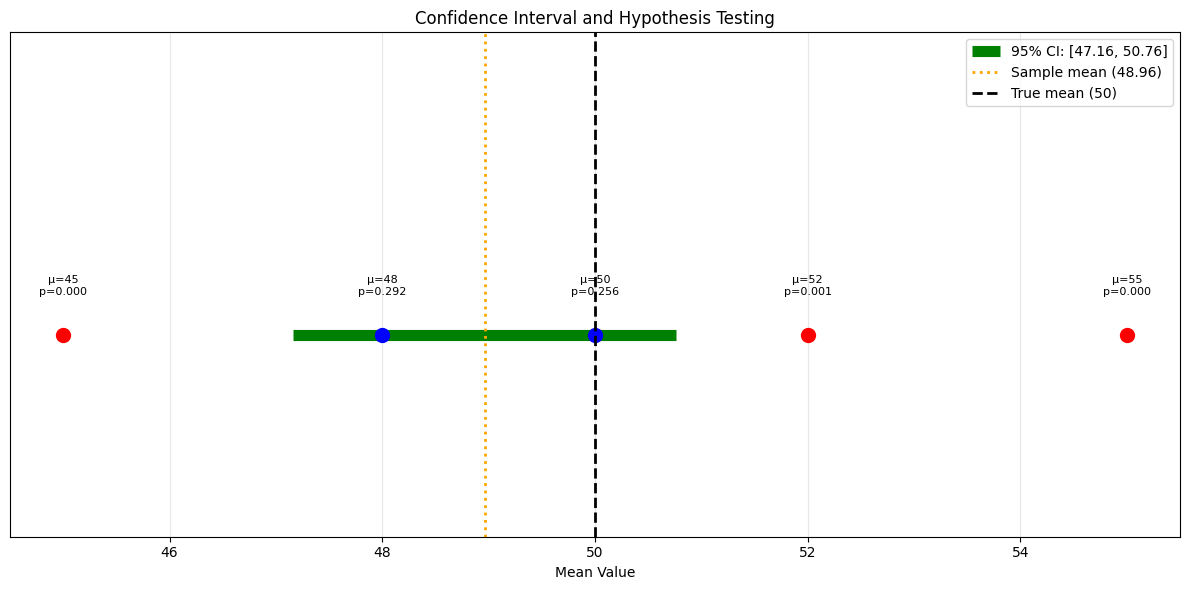


✅ Relationship between p-values and confidence intervals demonstrated!


In [4]:
print("\n" + "=" * 60)
print("Part 3: Relationship Between P-values and Confidence Intervals")
print("=" * 60)

# Relationship: If 95% CI excludes H0 value, p < 0.05
print("\nKey Relationship:")
print("  If 95% CI excludes the hypothesized value, then p < 0.05")
print("  If 95% CI includes the hypothesized value, then p ≥ 0.05")

# Demonstrate with different hypothesized values
hypothesized_values = [45, 48, 50, 52, 55]

print(f"\nTesting different hypothesized means:")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\nHypothesized Value | In CI? | p-value | Reject H0?")

for h0_val in hypothesized_values:
    t_stat, p_val = stats.ttest_1samp(sample, h0_val)
    in_ci = ci_lower <= h0_val <= ci_upper
    reject = p_val < 0.05
    print(f"  {h0_val:6.1f}         | {'Yes' if in_ci else 'No':5} | {p_val:.4f} | {'Yes' if reject else 'No':8}")

# Visualize
plt.figure(figsize=(12, 6))
plt.hlines(0, ci_lower, ci_upper, colors='green', linewidth=8, label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
for h0_val in hypothesized_values:
    t_stat, p_val = stats.ttest_1samp(sample, h0_val)
    color = 'red' if p_val < 0.05 else 'blue'
    plt.plot(h0_val, 0, 'o', color=color, markersize=10)
    plt.text(h0_val, 0.02, f'μ={h0_val}\np={p_val:.3f}', ha='center', fontsize=8)
plt.axvline(sample_mean, color='orange', linestyle=':', linewidth=2, label=f'Sample mean ({sample_mean:.2f})')
plt.axvline(true_mean, color='black', linestyle='--', linewidth=2, label=f'True mean ({true_mean})')
plt.xlabel('Mean Value')
plt.ylabel('')
plt.title('Confidence Interval and Hypothesis Testing')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.ylim(-0.1, 0.15)
plt.yticks([])
plt.tight_layout()
plt.show()

print("\n✅ Relationship between p-values and confidence intervals demonstrated!")

## Summary

### Key Concepts:
1. **P-value**: Probability of observing data (or more extreme) if H0 is true
2. **Confidence Interval**: Range of plausible values for parameter
3. **Relationship**: 95% CI excludes H0 value ↔ p < 0.05
4. **Interpretation**: 
   - P-value: Evidence against H0 (lower = stronger evidence)
   - CI: Range of parameter values consistent with data

### Best Practices:
- Report both p-values and confidence intervals
- Don't interpret p-value as probability H0 is true
- Consider effect size, not just significance
- Use appropriate confidence level (usually 95%)

### Applications:
- Statistical inference
- Scientific reporting
- Decision making
- Quality control

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - P-values and confidence intervals practical content